In [30]:
import sys

sys.path.insert(0,  './tmpignore/conceptor')
from conceptor.utils import plot_embed_with_label
from conceptor import PreTrainer, FineTuner, loadconceptor #, get_minmal_epoch
from conceptor.utils import plot_embed_with_label, plot_performance, score2
from conceptor.tokenizer import CANCER_CODE

In [31]:
import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.3)
import warnings
warnings.filterwarnings("ignore")

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

## Download finetuned model
### dowanload the finetuner models from [here](https://drive.google.com/drive/folders/1G4hFZd90uBmggeBFWYDW-crX2wsvuah_)

In [32]:
## load finetuner, your can load any finetuners
## finetuner_all_50.pt, finetuner_all_40.pt, finetuner_without_gide.pt
## Here we load finetuner_without_gide.pt to test the Gide cohort performance:

finetuner = loadconceptor('./tmpignore/finetuner_without_gide.pt')

## read data
df_label = pd.read_pickle('./tmpignore/ITRP.PATIENT.TABLE')
df_tpm = pd.read_pickle('./tmpignore/ITRP.TPM.TABLE')

df_label = df_label[df_label.cohort == 'Gide']
df_tpm = df_tpm.loc[df_label.index]

df_tpm.shape, df_label.shape

((73, 15672), (73, 110))

## Prepare model inputs

In [33]:
dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
df_task = onehot(df_label.response_label)
dfcx.head()

,cancer_code,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Index,,,,,,,,,,,,,,,,,,,,,
1_ipiPD1_PRE,25,5.23,0.02,82.96,0.10,0.75,0.03,27.57,3.23,0.04,...,10.48,3.47,0.70,1.63,2.43,0.05,2.98,10.81,6.30,4.01
2_ipiPD1_PRE,25,7.39,0.00,1154.40,0.00,0.95,0.03,48.91,2.10,0.01,...,17.20,7.46,0.44,0.79,5.81,0.00,5.02,37.27,13.47,8.14
6_ipiPD1_PRE,25,3.91,0.00,168.14,0.11,0.52,0.01,18.20,2.08,0.00,...,4.73,1.54,0.57,1.06,1.81,0.01,2.79,4.11,6.77,3.74
7_ipiPD1_PRE,25,1.85,0.01,80.62,0.00,0.21,0.03,4.82,0.84,0.06,...,4.07,1.58,0.44,0.39,0.87,0.00,2.00,8.44,2.20,2.92
8_ipiPD1_PRE,25,5.39,0.00,76.01,0.02,0.81,0.09,49.43,3.93,0.00,...,14.25,10.21,0.89,1.91,3.05,0.03,11.61,17.74,7.96,18.08


## Make predictions

In [34]:
dfe, df_pred = finetuner.predict(dfcx, batch_size = 16)

100%|##########| 5/5 [00:00<00:00,  6.13it/s]


The prediction of the model contains 2 outputs. The first output is the score of the cell-type level concepts. The second is the predicted probability. 0 corresponds to non-response and 1 corresponds to response.

In [35]:
## conceptor score
dfe.head()

,Adipocyte,Apoptosis_pathway,Bcell,CANCER,CD4_Tcell,CD8_Tcell,CPI_Response,CPI_effect,Cytokine_chemokine,Cytotoxic_Tcell,...,Stem,Stroma,TGFb_pathway,TLS,TMB,Tcell_exclusion,Tcell_general,Treg,cDC,pDC
Index,,,,,,,,,,,,,,,,,,,,,
1_ipiPD1_PRE,1.946114,2.308815,1.268282,-0.543625,1.952781,2.179384,1.341070,1.850306,2.191977,1.561325,...,1.865696,2.445551,1.399902,1.656181,1.957647,2.202881,2.109776,1.358847,1.394624,1.409620
2_ipiPD1_PRE,1.797584,2.147074,1.385810,-0.543746,1.896353,2.264272,0.690322,1.905378,2.098906,1.571620,...,2.329527,2.331889,1.670644,1.729452,1.884305,2.308213,2.294847,1.057095,1.322861,1.641564
6_ipiPD1_PRE,1.906188,2.301974,1.043642,-0.543417,1.945815,2.360919,1.212628,1.899567,2.061909,1.662967,...,2.018662,2.398139,1.444633,1.215814,1.696890,2.053318,2.169455,1.283464,1.484758,1.247126
7_ipiPD1_PRE,2.020110,2.352570,1.356010,-0.543264,1.973025,2.315243,1.371591,1.970148,2.251877,1.642058,...,2.094480,2.469353,1.384351,1.641669,1.575712,2.238491,2.118487,1.298826,1.560758,1.381392
8_ipiPD1_PRE,1.821828,2.048581,1.024990,-0.543961,1.918190,2.438015,0.937945,1.834857,2.089520,1.717699,...,2.145675,2.337186,1.359336,1.514439,1.842595,1.866308,2.208838,1.179389,1.387992,1.456456


In [36]:
## conceptor prediction probabilities
df_pred.head()

,0,1
Index,,
1_ipiPD1_PRE,0.399619,0.600381
2_ipiPD1_PRE,0.997979,0.002022
6_ipiPD1_PRE,0.939994,0.060006
7_ipiPD1_PRE,0.047343,0.952657
8_ipiPD1_PRE,0.999004,0.000996


## Analysis performance

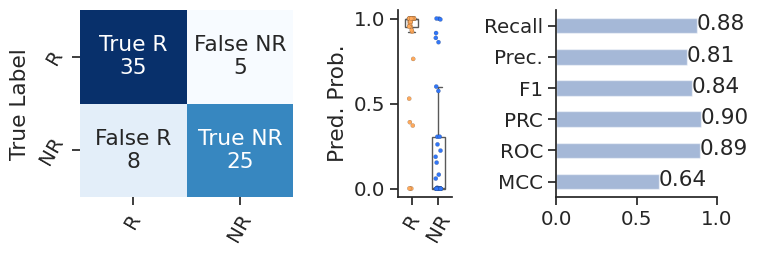

In [37]:
## masure the performance
dfp = df_task.join(df_pred)
y_true, y_prob, y_pred = dfp['R'], dfp[1], dfp[[0, 1]].idxmax(axis=1)
fig = plot_performance(y_true, y_prob, y_pred)

In [38]:
roc, prc, f1, acc, mcc = score2(y_true, y_prob, y_pred)
print("Test performance:roc={:.3f},prc={:.3f}, f1={:.3f}, acc={:.3f}, mcc={:.3f}.".format(roc, prc, f1, acc, mcc))

Test performance:roc=0.895,prc=0.903, f1=0.843, acc=0.822, mcc=0.640.
